# Notebook 15 (V4_3) — Time-Invariant AHP-Pattern Calibration Search

This notebook searches for a **qualitative** match to the AHP NFA decomposition, not a 100% replication. The target mechanism is a large negative movement in U.S. NFA generated mainly by price revaluation of large foreign-held U.S. equity claims, while the quantity-flow current account remains comparatively smooth.

The notebook is self-contained: it activates the repository project, includes TwoCountryProductionOLG.jl, diagnoses the saved Notebook 12 path, solves a modest staged catalog, certifies every candidate, shortlists the two lowest-score hard-valid cases, and selects between them at the T=35 reporting horizon before exporting tables and figures. T=45 is deliberately not used because this local nonlinear branch becomes horizon-stiff there; T=35 is long enough to assess the qualitative mechanism requested here.

A key restriction is common_world_growth=false. Thus every primitive in the catalog is time invariant and the literal values of nu_b and xi_W are retained; no runtime common-growth recalibration is permitted.


In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not locate Project.toml from $(start_dir)")
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))

using DelimitedFiles
using Plots, Printf, Statistics, LinearAlgebra
using Plots.PlotMeasures

gr()

const DEFAULT_OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                                "ahp_pattern_time_invariant_search")
const OUTDIR = get(ENV, "NB15_OUTDIR", DEFAULT_OUTDIR)
const BASELINE_DIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                              "hkt_increasing_q_large_bubble_share_common_growth")
mkpath(OUTDIR)

const RESID_TOL = 1e-5
const PSI_INTERIOR_TOL = 0.02
const EQUITY_INTERIOR_TOL = 0.01
const THETA_INTERIOR_TOL = 0.01
const ACCOUNTING_SCALED_TOL = 1e-7
const AHP_ASSET_VA_ANCHOR_2010_2020 = 0.413
const AHP_LIABILITY_VA_ANCHOR_2010_2020 = -1.036
const AHP_NET_VA_ANCHOR_2010_2020 = -0.623

# Default execution is the requested search. NB15_SMOKE=1 is only a developer
# control for a quick sequential plumbing check; it is never used for reported results.
const SMOKE_MODE = get(ENV, "NB15_SMOKE", "0") == "1"
const SEARCH_T = SMOKE_MODE ? 8 : 30
const SEARCH_BUFFER = SMOKE_MODE ? 4 : 10
const FINAL_HORIZONS = SMOKE_MODE ? [10] : [35]
const FINAL_BUFFER = SMOKE_MODE ? 4 : 10
const REPORTING_FINALIST_COUNT = SMOKE_MODE ? 1 : 2

default(size=(950, 520), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=9mm, right_margin=7mm, top_margin=7mm, bottom_margin=8mm)

println("Julia version:       ", VERSION)
println("Project directory:   ", PROJECT_DIR)
println("Baseline directory:  ", BASELINE_DIR)
println("Output directory:    ", OUTDIR)
println("Execution mode:      ", SMOKE_MODE ? "SMOKE (not for reporting)" : "FULL")
println("Search horizon:      ", SEARCH_T)
println("Final horizons:      ", join(FINAL_HORIZONS, " -> "))


  Activating 

Julia version:       1

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


.12.1
Project directory:   /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes
Baseline directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_increasing_q_large_bubble_share_common_growth
Output directory:    /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search
Execution mode:      FULL
Search horizon:      30
Final horizons:      35


## 1. Why Notebook 12's normalized cumulative CA rises and then falls

The saved Notebook 12 numerator is not reversing: raw cumulative CA is monotone increasing. The `_y` figure divides this historical cumulative sum by **current** U.S. output, while `combo_ahp_style_two_panel_components_e.png` divides it by **current** U.S. equity value `e_US` (not output). In the saved path, `Y_US` grows by roughly 500 times and `e_US` by roughly 535 times. Once either current denominator grows faster than cumulative CA, the displayed ratio must fall even though cumulative CA is still increasing.

This is a denominator effect, not a late reversal of the raw cumulative current account. The cell below verifies both normalizations directly from the baseline CSVs with DelimitedFiles only. The new calibration retains current-Y-normalized paths for direct comparison, but scores late-window movements using one fixed endpoint denominator, `Y_US,T`. The latter keeps the exact accounting identity visible without a moving denominator manufacturing a hump.


In [2]:
function read_numeric_csv(path::AbstractString)
    isfile(path) || error("Required baseline CSV not found: $(path)")
    data, header = readdlm(path, ',', Float64, '\n'; header=true)
    data_matrix = ndims(data) == 1 ? reshape(data, 1, :) : data
    names = String.(vec(header))
    size(data_matrix, 2) == length(names) ||
        error("Header/data column mismatch in $(path)")
    return Dict(names[j] => Float64.(data_matrix[:, j]) for j in eachindex(names))
end

function require_columns(table, names, label)
    missing_names = filter(name -> !haskey(table, name), names)
    isempty(missing_names) ||
        error("Missing columns in $(label): $(join(missing_names, ", "))")
end

baseline_ahp = read_numeric_csv(joinpath(BASELINE_DIR, "combo_ahp_style_decomposition.csv"))
baseline_cumulative = read_numeric_csv(joinpath(BASELINE_DIR, "combo_ahp_cumulative_va_ca_subcomponents_y.csv"))
baseline_paths = read_numeric_csv(joinpath(BASELINE_DIR, "combo_all_u_endogenous_paths.csv"))

require_columns(baseline_ahp, ["t", "cum_CA", "Y_US", "e_US"], "baseline AHP accounting")
require_columns(baseline_cumulative, ["t", "cum_CA_total_Y", "Y_US"], "baseline cumulative subcomponents")
require_columns(baseline_paths, ["t", "Y_US"], "baseline endogenous paths")

base_cum_CA = baseline_ahp["cum_CA"]
base_Y = baseline_ahp["Y_US"]
base_e = baseline_ahp["e_US"]
base_cum_CA_over_current_Y = base_cum_CA ./ base_Y
base_cum_CA_over_current_e = base_cum_CA ./ base_e
base_scale = max(1.0, maximum(abs.(base_cum_CA)))
base_raw_monotone = all(diff(base_cum_CA) .>= -1e-12 * base_scale)
base_Y_growth = base_Y[end] / base_Y[1]
base_e_growth = base_e[end] / base_e[1]
base_CA_peak_t = Int(round(baseline_ahp["t"][argmax(base_cum_CA_over_current_Y)]))
base_CA_e_peak_t = Int(round(baseline_ahp["t"][argmax(base_cum_CA_over_current_e)]))
base_CA_ratio_peak = maximum(base_cum_CA_over_current_Y)
base_CA_ratio_final = base_cum_CA_over_current_Y[end]
base_CA_backtracking = max(0.0, base_CA_ratio_peak - base_CA_ratio_final)
base_CA_e_ratio_peak = maximum(base_cum_CA_over_current_e)
base_CA_e_ratio_final = base_cum_CA_over_current_e[end]
base_CA_e_backtracking = max(0.0, base_CA_e_ratio_peak - base_CA_e_ratio_final)
base_ratio_csv_error = maximum(abs.(base_cum_CA_over_current_Y .-
                                    baseline_cumulative["cum_CA_total_Y"]))
base_Y_csv_error = maximum(abs.(base_Y .- baseline_paths["Y_US"]))

diagnosis_rows = Dict{String,Any}[
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"raw_cum_CA_monotone",
         "value"=>base_raw_monotone,
         "interpretation"=>"Raw cumulative CA never reverses within numerical tolerance."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"raw_cum_CA_final",
         "value"=>base_cum_CA[end],
         "interpretation"=>"The numerator continues to rise through the endpoint."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"Y_US_growth_T_over_1",
         "value"=>base_Y_growth,
         "interpretation"=>"Current U.S. output is the rapidly expanding denominator."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_Y_peak",
         "value"=>base_CA_ratio_peak,
         "interpretation"=>"Peak of the moving-denominator ratio."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_Y_final",
         "value"=>base_CA_ratio_final,
         "interpretation"=>"Endpoint after output growth outruns cumulative CA."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_ratio_backtracking",
         "value"=>base_CA_backtracking,
         "interpretation"=>"Peak minus endpoint; denominator-driven because raw cum CA is monotone."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"e_US_growth_T_over_1",
         "value"=>base_e_growth,
         "interpretation"=>"Current U.S. equity value is the denominator in the `_e` figure."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_peak",
         "value"=>base_CA_e_ratio_peak,
         "interpretation"=>"Peak of cumulative CA divided by current e_US."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_final",
         "value"=>base_CA_e_ratio_final,
         "interpretation"=>"Endpoint after e_US growth outruns cumulative CA."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_over_current_e_backtracking",
         "value"=>base_CA_e_backtracking,
         "interpretation"=>"Peak minus endpoint in the `_e` figure; also denominator-driven."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"cum_CA_ratio_cross_csv_error",
         "value"=>base_ratio_csv_error,
         "interpretation"=>"Agreement between the two saved Notebook 12 accounting CSVs."),
    Dict("scope"=>"Notebook 12 baseline", "metric"=>"Y_US_cross_csv_error",
         "value"=>base_Y_csv_error,
         "interpretation"=>"Agreement with the saved all-u endogenous-path CSV.")
]

@printf("\nNotebook 12 denominator diagnosis\n")
@printf("  raw cumulative CA monotone: %s\n", base_raw_monotone)
@printf("  raw cumulative CA:          %.6g -> %.6g\n", base_cum_CA[1], base_cum_CA[end])
@printf("  Y_US growth:                %.3fx\n", base_Y_growth)
@printf("  cum CA/current Y peak:      %.6f at t=%d\n", base_CA_ratio_peak, base_CA_peak_t)
@printf("  cum CA/current Y endpoint:  %.6f\n", base_CA_ratio_final)
@printf("  Y denominator backtracking: %.6f\n", base_CA_backtracking)
@printf("  e_US growth:                 %.3fx\n", base_e_growth)
@printf("  cum CA/current e peak:       %.6f at t=%d\n", base_CA_e_ratio_peak, base_CA_e_peak_t)
@printf("  cum CA/current e endpoint:   %.6f\n", base_CA_e_ratio_final)
@printf("  e denominator backtracking: %.6f\n\n", base_CA_e_backtracking)

base_raw_monotone || error("Saved baseline no longer supports the monotone-raw-CA diagnosis.")
base_Y_growth > 100 || @warn "Baseline Y growth is much smaller than the documented roughly 500x path." base_Y_growth
base_e_growth > 100 || @warn "Baseline e_US growth is much smaller than the documented roughly 535x path." base_e_growth



Notebook 12 denominator diagnosis
  raw cumulative CA monotone: true
  raw cumulative CA:          0 -> 49.6344
  Y_US growth:                499.887x
  cum CA/current Y peak:      0.114148 at t=25
  cum CA/current Y endpoint:  0.057247
  Y denominator backtracking: 0.056901
  e_US growth:                 534.926x
  cum CA/current e peak:       0.114521 at t=24
  cum CA/current e endpoint:   0.055216
  e denominator backtracking: 0.059304



true

## 2. Exact AHP accounting and two normalizations

For U.S. holdings of RoW equity n_W, foreign holdings of U.S. equity n_US_star, and the U.S. bond position b,

NFA_t = q_W,t n_W,t + b_t - q_US,t n_US_star,t.

For each transition, the product rule is exact in discrete time when quantity changes use current prices and price changes use lagged quantities:

VA_t = n_W,t-1 Delta q_W,t - n_US_star,t-1 Delta q_US,t

CA_t = q_W,t Delta n_W,t - q_US,t Delta n_US_star,t + Delta b_t.

The implementation also retains every asset, liability, and bond subcomponent. It reports four distinct objects without conflating them:

1. the primary AHP normalization: cumulate nominal flows first, then divide each cumulative stock/flow by current Y_US,t;
2. the actual level ratio NFA_t / Y_US,t, whose deterioration is required for an economic pattern pass;
3. period-normalized cumulative flows, cumsum(flow_t / Y_US,t), retained only as a clearly labelled secondary diagnostic;
4. late-window endpoint normalization: all nominal changes since the late-window start divided by the single Y_US,T, used to isolate the revaluation mechanism.

The score prioritizes the AHP/current-output NFA ratio direction and uses the fixed-endpoint decomposition only as a mechanism diagnostic. The 2010–2020 anchors asset +0.413, liability -1.036, and net -0.623 are reference distances only, not exact calibration targets.


In [3]:
path_vector(result, field::Symbol) = Float64[getfield(s, field) for s in result.u_path]

# Pre-registered AHP comparison window: the second half of every solved path.
late_start_index(T::Int) = max(1, fld(T, 2))

function cumulative_since(x::AbstractVector, start::Int)
    out = zeros(Float64, length(x))
    for t in (start + 1):length(x)
        out[t] = out[t - 1] + x[t]
    end
    return out
end

turnover_reversal(x::AbstractVector) =
    0.5 * max(0.0, sum(abs, x) - abs(sum(x)))

function ahp_accounting(result::ProductionSimulationResult)
    T = length(result.u_path)
    T >= 3 || error("AHP accounting needs at least three periods.")

    q_US = path_vector(result, :q_US)
    q_W = path_vector(result, :q_W)
    Y_US = path_vector(result, :Y_US)
    e_US = path_vector(result, :e_US)

    n_W = Float64[(1 - s.ω) * (1 - s.θ) * s.A / s.q_W for s in result.u_path]
    n_US_star = Float64[s.ω_star * (1 - s.θ_US_star) * s.A_star / s.q_US
                        for s in result.u_path]
    bond = Float64[s.θ * s.A for s in result.u_path]

    asset_position = q_W .* n_W
    liability_position = q_US .* n_US_star
    NFA = asset_position .+ bond .- liability_position

    VA_asset = zeros(T)
    VA_liability = zeros(T)
    CA_asset = zeros(T)
    CA_liability = zeros(T)
    CA_bond = zeros(T)

    for t in 2:T
        VA_asset[t] = n_W[t - 1] * (q_W[t] - q_W[t - 1])
        VA_liability[t] = -n_US_star[t - 1] * (q_US[t] - q_US[t - 1])
        CA_asset[t] = q_W[t] * (n_W[t] - n_W[t - 1])
        CA_liability[t] = -q_US[t] * (n_US_star[t] - n_US_star[t - 1])
        CA_bond[t] = bond[t] - bond[t - 1]
    end

    VA = VA_asset .+ VA_liability
    CA = CA_asset .+ CA_liability .+ CA_bond
    ΔNFA = zeros(T)
    RES = zeros(T)
    for t in 2:T
        ΔNFA[t] = NFA[t] - NFA[t - 1]
        RES[t] = ΔNFA[t] - CA[t] - VA[t]
    end

    cum_VA_asset = cumsum(VA_asset)
    cum_VA_liability = cumsum(VA_liability)
    cum_CA_asset = cumsum(CA_asset)
    cum_CA_liability = cumsum(CA_liability)
    cum_CA_bond = cumsum(CA_bond)
    cum_VA = cumsum(VA)
    cum_CA = cumsum(CA)
    cum_RES = cumsum(RES)
    accounting_line = NFA[1] .+ cum_CA .+ cum_VA .+ cum_RES

    # Period-normalized flows are a secondary diagnostic, not the AHP figure.
    # AHP cumulates nominal flows first and divides the cumulative sum by current Y.
    ΔNFA_current_Y = ΔNFA ./ Y_US
    CA_current_Y = CA ./ Y_US
    VA_current_Y = VA ./ Y_US
    RES_current_Y = RES ./ Y_US
    VA_asset_current_Y = VA_asset ./ Y_US
    VA_liability_current_Y = VA_liability ./ Y_US
    CA_asset_current_Y = CA_asset ./ Y_US
    CA_liability_current_Y = CA_liability ./ Y_US
    CA_bond_current_Y = CA_bond ./ Y_US
    periodnorm_cum_ΔNFA = cumsum(ΔNFA_current_Y)
    periodnorm_cum_CA = cumsum(CA_current_Y)
    periodnorm_cum_VA = cumsum(VA_current_Y)
    periodnorm_cum_RES = cumsum(RES_current_Y)

    late_start = late_start_index(T)
    late_cum_VA_asset = cumulative_since(VA_asset, late_start)
    late_cum_VA_liability = cumulative_since(VA_liability, late_start)
    late_cum_CA_asset = cumulative_since(CA_asset, late_start)
    late_cum_CA_liability = cumulative_since(CA_liability, late_start)
    late_cum_CA_bond = cumulative_since(CA_bond, late_start)
    late_cum_VA = cumulative_since(VA, late_start)
    late_cum_CA = cumulative_since(CA, late_start)
    late_cum_RES = cumulative_since(RES, late_start)
    late_accounting_line = NFA[late_start] .+ late_cum_CA .+ late_cum_VA .+ late_cum_RES

    module_NFA = nfa_decomposition(result).NFA
    return (T=T, q_US=q_US, q_W=q_W, Y_US=Y_US, e_US=e_US,
            n_W=n_W, n_US_star=n_US_star, bond=bond,
            asset_position=asset_position, liability_position=liability_position,
            NFA=NFA, ΔNFA=ΔNFA, module_NFA=module_NFA,
            VA_asset=VA_asset, VA_liability=VA_liability, VA=VA,
            CA_asset=CA_asset, CA_liability=CA_liability, CA_bond=CA_bond, CA=CA,
            RES=RES,
            cum_VA_asset=cum_VA_asset, cum_VA_liability=cum_VA_liability,
            cum_CA_asset=cum_CA_asset, cum_CA_liability=cum_CA_liability,
            cum_CA_bond=cum_CA_bond, cum_VA=cum_VA, cum_CA=cum_CA,
            cum_RES=cum_RES, accounting_line=accounting_line,
            ΔNFA_current_Y=ΔNFA_current_Y, CA_current_Y=CA_current_Y,
            VA_current_Y=VA_current_Y, RES_current_Y=RES_current_Y,
            VA_asset_current_Y=VA_asset_current_Y,
            VA_liability_current_Y=VA_liability_current_Y,
            CA_asset_current_Y=CA_asset_current_Y,
            CA_liability_current_Y=CA_liability_current_Y,
            CA_bond_current_Y=CA_bond_current_Y,
            periodnorm_cum_ΔNFA=periodnorm_cum_ΔNFA,
            periodnorm_cum_CA=periodnorm_cum_CA,
            periodnorm_cum_VA=periodnorm_cum_VA,
            periodnorm_cum_RES=periodnorm_cum_RES,
            late_start=late_start,
            late_cum_VA_asset=late_cum_VA_asset,
            late_cum_VA_liability=late_cum_VA_liability,
            late_cum_CA_asset=late_cum_CA_asset,
            late_cum_CA_liability=late_cum_CA_liability,
            late_cum_CA_bond=late_cum_CA_bond,
            late_cum_VA=late_cum_VA, late_cum_CA=late_cum_CA,
            late_cum_RES=late_cum_RES,
            late_accounting_line=late_accounting_line,
            residual_max=maximum(abs.(RES[2:end])),
            nfa_identity_error=maximum(abs.(NFA .- module_NFA)))
end

function candidate_metrics(a)
    Y = a.Y_US
    i0 = a.late_start
    late = (i0 + 1):a.T
    ahp_cum_CA_current_Y = a.cum_CA ./ Y
    ca_backtracking = turnover_reversal(a.CA_current_Y[2:end])
    late_ca_backtracking = turnover_reversal(a.CA_current_Y[late])
    moving_denominator_backtracking = turnover_reversal(diff(ahp_cum_CA_current_Y))
    ca_tv_excess = 2.0 * ca_backtracking

    late_nfa_move = (a.NFA[end] - a.NFA[i0]) / Y[end]
    late_periodnorm_nfa_sum = sum(a.ΔNFA_current_Y[late])
    late_ratio_change = a.NFA[end] / Y[end] - a.NFA[i0] / Y[i0]
    late_va_asset = a.late_cum_VA_asset[end] / Y[end]
    late_va_liability = a.late_cum_VA_liability[end] / Y[end]
    late_va_net = a.late_cum_VA[end] / Y[end]
    late_ca = a.late_cum_CA[end] / Y[end]
    late_residual = a.late_cum_RES[end] / Y[end]
    liability_dominance = abs(late_va_liability) / max(abs(late_va_asset), 1e-8)
    liability_dominance_share = abs(late_va_liability) /
        max(abs(late_va_asset) + abs(late_va_liability), 1e-8)
    late_foreign_exposure = mean(a.liability_position[late] ./ Y[late])
    late_asset_exposure = mean(a.asset_position[late] ./ Y[late])
    ca_flow_rms = sqrt(mean((a.CA[late] ./ Y[late]).^2))
    ca_roughness = std(a.CA_current_Y[late]; corrected=false)
    va_driver_share = abs(late_va_net) /
        max(abs(late_va_net) + abs(late_ca), 1e-8)
    ca_share = abs(late_ca) / max(abs(late_va_net) + abs(late_ca), 1e-8)
    whole_path_nfa_move = (a.NFA[end] - a.NFA[1]) / Y[end]
    full_ratio_change = a.NFA[end] / Y[end] - a.NFA[1] / Y[1]
    full_path_match = whole_path_nfa_move <= -0.05 && full_ratio_change <= -0.05
    nfa_initial_current_Y = a.NFA[1] / Y[1]
    nfa_final_current_Y = a.NFA[end] / Y[end]
    anchor_distance = sqrt(
        (late_va_asset - AHP_ASSET_VA_ANCHOR_2010_2020)^2 +
        (late_va_liability - AHP_LIABILITY_VA_ANCHOR_2010_2020)^2 +
        (late_va_net - AHP_NET_VA_ANCHOR_2010_2020)^2
    )

    return (late_start=i0,
            late_nfa_move=late_nfa_move,
            late_periodnorm_nfa_sum=late_periodnorm_nfa_sum,
            late_ratio_change=late_ratio_change,
            late_va_asset=late_va_asset,
            late_va_liability=late_va_liability,
            late_va_net=late_va_net,
            late_ca=late_ca,
            late_residual=late_residual,
            liability_dominance=liability_dominance,
            liability_dominance_share=liability_dominance_share,
            late_foreign_exposure=late_foreign_exposure,
            late_asset_exposure=late_asset_exposure,
            ca_backtracking=ca_backtracking,
            late_ca_backtracking=late_ca_backtracking,
            moving_denominator_backtracking=moving_denominator_backtracking,
            ca_tv_excess=ca_tv_excess,
            ca_flow_rms=ca_flow_rms,
            ca_roughness=ca_roughness,
            va_driver_share=va_driver_share,
            ca_share=ca_share,
            whole_path_nfa_move=whole_path_nfa_move,
            full_ratio_change=full_ratio_change,
            full_path_match=full_path_match,
            nfa_initial_current_Y=nfa_initial_current_Y,
            nfa_final_current_Y=nfa_final_current_Y,
            anchor_distance=anchor_distance,
            Y_growth=Y[end] / Y[1],
            q_US_growth=a.q_US[end] / a.q_US[1],
            q_W_growth=a.q_W[end] / a.q_W[1])
end

function hard_validity(result, a)
    theta_US_star = path_vector(result, :θ_US_star)
    finite_accounting = all(isfinite, a.NFA) && all(isfinite, a.CA) &&
                        all(isfinite, a.VA) && all(isfinite, a.Y_US)
    model_residuals = result.branch_converged &&
                      isfinite(result.max_u_residual) &&
                      isfinite(result.max_bgp_residual) &&
                      result.max_u_residual <= RESID_TOL &&
                      result.max_bgp_residual <= RESID_TOL
    psi_interior = result.diagnostics.psi_ok &&
                   isfinite(result.diagnostics.psi_min) &&
                   result.diagnostics.psi_min >= PSI_INTERIOR_TOL
    equity_interior = result.diagnostics.equity_weights_ok &&
                      isfinite(result.diagnostics.equity_weight_min) &&
                      result.diagnostics.equity_weight_min >= EQUITY_INTERIOR_TOL
    theta_interior = all(x -> isfinite(x) && THETA_INTERIOR_TOL <= x < 0.9,
                         theta_US_star)
    positive_foreign_claims = all(x -> isfinite(x) && x > 0.0, a.n_US_star) &&
                              all(x -> isfinite(x) && x > 0.0, a.liability_position)
    accounting_scale = max(1.0, maximum(abs.(a.NFA)), maximum(abs.(a.CA)),
                           maximum(abs.(a.VA)))
    accounting_exact = isfinite(a.residual_max) && a.residual_max <= RESID_TOL &&
                       a.residual_max / accounting_scale <= ACCOUNTING_SCALED_TOL &&
                       isfinite(a.nfa_identity_error) &&
                       a.nfa_identity_error / accounting_scale <= ACCOUNTING_SCALED_TOL
    return_fields = (:R_A_u, :R_A_b, :R_A_star_u, :R_A_star_b, :R_f, :R_f_W)
    positive_returns = all(field -> all(x -> isfinite(x) && x > 0.0,
                                            path_vector(result, field)), return_fields)
    positive_output = all(x -> isfinite(x) && x > 0.0, a.Y_US)

    valid = model_residuals && psi_interior && equity_interior &&
            theta_interior && positive_foreign_claims && positive_returns && accounting_exact &&
            positive_output && finite_accounting
    return (valid=valid, model_residuals=model_residuals,
            psi_interior=psi_interior, equity_interior=equity_interior,
            theta_interior=theta_interior,
            positive_foreign_claims=positive_foreign_claims,
            positive_returns=positive_returns,
            accounting_exact=accounting_exact,
            positive_output=positive_output,
            finite_accounting=finite_accounting)
end

# Lower is better. Directional failures receive much larger weights than
# the AHP level-distance anchor, so the score remains a qualitative pattern score.
function economic_classification(m)
    strong = m.late_nfa_move <= -0.02 && m.late_ratio_change <= -0.02 &&
             m.full_ratio_change <= -0.02 && m.late_va_liability <= -0.04 &&
             m.late_va_net <= -0.03 && m.late_foreign_exposure >= 0.30 &&
             m.va_driver_share >= 0.60 && m.liability_dominance_share >= 0.70 &&
             m.ca_share <= 0.50 && m.moving_denominator_backtracking <= 0.10 &&
             m.ca_roughness <= 0.02
    partial = m.whole_path_nfa_move < 0.0 && m.full_ratio_change < 0.0 &&
              m.late_va_liability < 0.0 && m.late_va_net < 0.0 &&
              m.liability_dominance_share > 0.50 &&
              m.va_driver_share > 0.50 && m.late_foreign_exposure > 0.10
    mechanism_near_miss = m.late_nfa_move < 0.0 &&
                          m.late_va_liability < 0.0 && m.late_va_net < 0.0 &&
                          m.liability_dominance_share > 0.50 &&
                          m.va_driver_share > 0.50 && m.late_foreign_exposure > 0.10
    return strong ? "strong_pattern" :
           partial ? "partial_ahp_pattern" :
           mechanism_near_miss ? "liability_revaluation_near_miss" : "near_miss"
end

function relaxed_ahp_score(m)
    nfa_direction_penalty = max(0.0, m.late_nfa_move + 0.10)
    periodnorm_penalty = max(0.0, m.late_periodnorm_nfa_sum + 0.02)
    ratio_change_penalty = max(0.0, m.late_ratio_change + 0.02)
    full_ratio_change_penalty = max(0.0, m.full_ratio_change + 0.02)
    liability_direction_penalty = max(0.0, m.late_va_liability + 0.10)
    net_va_direction_penalty = max(0.0, m.late_va_net + 0.05)
    dominance_penalty = max(0.0, 0.70 - m.liability_dominance_share)
    va_driver_penalty = max(0.0, 0.60 - m.va_driver_share)
    ca_share_penalty = max(0.0, m.ca_share - 0.50)
    exposure_penalty = max(0.0, 0.20 - m.late_foreign_exposure)
    whole_path_penalty = max(0.0, m.whole_path_nfa_move)

    return 10.0 * nfa_direction_penalty +
            0.5 * periodnorm_penalty +
           20.0 * ratio_change_penalty +
           12.0 * full_ratio_change_penalty +
           10.0 * liability_direction_penalty +
            4.0 * net_va_direction_penalty +
            1.5 * dominance_penalty +
            1.5 * va_driver_penalty +
            1.0 * ca_share_penalty +
            5.0 * abs(m.late_ca) +
            1.0 * m.ca_backtracking +
            4.0 * m.late_ca_backtracking +
            1.0 * m.moving_denominator_backtracking +
            1.0 * m.ca_flow_rms +
            2.0 * exposure_penalty +
            0.25 * whole_path_penalty +
            0.10 * abs(m.nfa_initial_current_Y) +
            0.15 * m.anchor_distance
end


relaxed_ahp_score (generic function with 1 method)

## 3. Small staged candidate catalog

This is a local, sequential catalog rather than a Cartesian grid. It is centered on the residual-safe mechanism block identified in prior probes: higher U.S. equity payout share, large foreign exposure, negative liability VA, and a negative NFA movement despite smooth net CA. One-at-a-time perturbations in beta, vartheta_US, and the two gross equity targets isolate which margin improves the pattern.

The stages deliberately cover:

- beta, which changes saving and the scale of gross positions;
- vartheta_US, which changes how strongly a U.S. equity price movement revalues lagged foreign claims;
- omega_bar and omega_bar_star, which rebalance initial gross positions while retaining large foreign-held U.S. equity claims.

Known stiff, infeasible, or off-mechanism directions are excluded: a_US at or below 0.12 with high exponents, eta at or below 0.001, persistence at or above 0.85, beta at or above 0.60 in this high-exposure block, omega_bar below its model floor 0.50, RoW scale at or above 10, and lower-growth exponent probes that either reverse liability VA or make CA dominate. The present catalog keeps a_US=0.20, eta=0.01, persistence=0.80, and RoW scale 3.


In [4]:
Base.@kwdef struct CandidateSpec
    label::String
    stage::String
    note::String
    β::Float64 = 0.50
    γ::Float64 = 0.25
    π_persist::Float64 = 0.80
    a_US::Float64 = 0.20
    ϑ_US::Float64 = 0.50
    a_W::Float64 = 0.0666667
    H_W::Float64 = 3.0
    L_W::Float64 = 3.0
    ν_b::Float64 = 0.10
    ν_u::Float64 = 1.40
    ξ_u::Float64 = 1.90
    ξ_W::Float64 = 0.10
    ωbar::Float64 = 0.90
    ωbar_star::Float64 = 0.35
    κ::Float64 = 0.10
    χ::Float64 = 0.005
    η::Float64 = 0.010
end

const CANDIDATES = CandidateSpec[
    CandidateSpec(label="A_beta050_reference", stage="beta",
        note="Residual-safe high-payout mechanism reference.",
        β=0.50, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.60, ωbar_star=0.40, κ=1.00, χ=0.0002),
    CandidateSpec(label="B_beta045_reference", stage="beta",
        note="Lower-beta robustness perturbation.",
        β=0.45, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.60, ωbar_star=0.40, κ=1.00, χ=0.0002),
    CandidateSpec(label="C_beta050_lower_payout", stage="payout_share",
        note="One-at-a-time lower U.S. payout-share perturbation.",
        β=0.50, ϑ_US=0.70, a_W=0.10, ξ_W=1.00,
        ωbar=0.60, ωbar_star=0.40, κ=1.00, χ=0.0002),
    CandidateSpec(label="D_home_weight_floor", stage="gross_positions",
        note="Raises U.S.-held foreign equity at the model's omega_bar floor.",
        β=0.45, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.50, ωbar_star=0.40, κ=1.00, χ=0.0002),
    CandidateSpec(label="E_foreign_target030", stage="gross_positions",
        note="Rebalances initial NFA while retaining large foreign U.S.-equity claims.",
        β=0.45, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.50, ωbar_star=0.30, κ=1.00, χ=0.0002),
    CandidateSpec(label="F_foreign_target025", stage="gross_positions",
        note="Strongest known full-path NFA/Y deterioration with liability-led VA.",
        β=0.45, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.50, ωbar_star=0.25, κ=1.00, χ=0.0002),
    CandidateSpec(label="G_foreign_target025_beta050", stage="beta",
        note="Beta robustness check around the best gross-position target.",
        β=0.50, ϑ_US=0.80, a_W=0.10, ξ_W=1.00,
        ωbar=0.50, ωbar_star=0.25, κ=1.00, χ=0.0002)
]

const EXCLUDED_DIRECTIONS = [
    "a_US <= 0.12 with high productivity exponents",
    "eta <= 0.001",
    "pi_persist >= 0.85",
    "beta >= 0.60 in the high-exposure block (hard-gate failure or stiffness)",
    "omega_bar < 0.50 (ruled out by ProductionParams validation)",
    "lower-growth exponent probes (positive liability VA or CA-dominated NFA)",
    "H_W = L_W >= 10",
    "broad structural-level cases that become stiff at T=30",
    "large Cartesian grids"
]

function params_for(c::CandidateSpec; T::Int, n_buffer::Int)
    p = ProductionParams(
        T_max=T,
        n_buffer=n_buffer,
        common_world_growth=false,
        β=c.β,
        γ=c.γ,
        π_persist=c.π_persist,
        a_US=c.a_US,
        ϑ_US=c.ϑ_US,
        a_W=c.a_W,
        H_W=c.H_W,
        L_W=c.L_W,
        ν_b=c.ν_b,
        ν_u=c.ν_u,
        ξ_u=c.ξ_u,
        ξ_W=c.ξ_W,
        ω̄=c.ωbar,
        ω̄_star=c.ωbar_star,
        κ=c.κ,
        χ=c.χ,
        η=c.η,
        branch_iters=60,
        do_global_polish=false
    )
    p.common_world_growth && error("Candidate construction violated time-invariant literal calibration.")
    return p
end

active_candidates = SMOKE_MODE ? CANDIDATES[1:2] : CANDIDATES

println("Candidate count: ", length(active_candidates))
println("Excluded stiff/extreme directions:")
foreach(x -> println("  - ", x), EXCLUDED_DIRECTIONS)


Candidate count: 7
Excluded stiff/extreme directions:
  - a_US <= 0.12 with high productivity exponents
  - eta <= 0.001
  - pi_persist >= 0.85
  - beta >= 0.60 in the high-exposure block (hard-gate failure or stiffness)
  - omega_bar < 0.50 (ruled out by ProductionParams validation)
  - lower-growth exponent probes (positive liability VA or CA-dominated NFA)
  - H_W = L_W >= 10
  - broad structural-level cases that become stiff at T=30
  - large Cartesian grids


In [5]:
function csv_cell(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s) || occursin('\r', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function row_value(row, column::String)
    row isa AbstractDict && return get(row, column, missing)
    symbol = Symbol(column)
    return hasproperty(row, symbol) ? getproperty(row, symbol) : missing
end

function write_rows_csv(path::AbstractString, rows, columns::Vector{String})
    open(path, "w") do io
        println(io, join(csv_cell.(columns), ","))
        for row in rows
            println(io, join((csv_cell(row_value(row, c)) for c in columns), ","))
        end
    end
    return path
end

function write_columns_csv(path::AbstractString, columns::Vector{String}, values)
    length(columns) == length(values) || error("CSV column/value mismatch.")
    isempty(values) && error("CSV export requires at least one column.")
    n = length(values[1])
    all(length(v) == n for v in values) || error("CSV columns have unequal lengths.")
    open(path, "w") do io
        println(io, join(csv_cell.(columns), ","))
        for i in 1:n
            println(io, join((csv_cell(values[j][i]) for j in eachindex(columns)), ","))
        end
    end
    return path
end

function base_row(c::CandidateSpec; T::Int, phase::String)
    return Dict{String,Any}(
        "phase"=>phase, "label"=>c.label, "stage"=>c.stage, "note"=>c.note,
        "T"=>T, "common_world_growth"=>false,
        "beta"=>c.β, "gamma"=>c.γ, "pi_persist"=>c.π_persist,
        "a_US"=>c.a_US, "vartheta_US"=>c.ϑ_US,
        "a_W"=>c.a_W, "H_W"=>c.H_W, "L_W"=>c.L_W,
        "nu_b"=>c.ν_b, "nu_u"=>c.ν_u, "xi_u"=>c.ξ_u, "xi_W"=>c.ξ_W,
        "omega_bar"=>c.ωbar, "omega_bar_star"=>c.ωbar_star,
        "kappa"=>c.κ, "chi"=>c.χ, "eta"=>c.η,
        "status"=>"not_run", "valid"=>false,
        "economic_classification"=>"not_evaluated",
        "economic_pass"=>false, "score"=>Inf
    )
end

function evaluate_candidate(c::CandidateSpec; T::Int, n_buffer::Int, phase::String)
    row = base_row(c; T=T, phase=phase)
    started = time()
    try
        p = params_for(c; T=T, n_buffer=n_buffer)
        result = run_production_simulation(p; verbose=false)
        p.common_world_growth && error("Solver returned common_world_growth=true.")
        accounting = ahp_accounting(result)
        metrics = candidate_metrics(accounting)
        checks = hard_validity(result, accounting)
        economic_class = economic_classification(metrics)
        score = checks.valid ? relaxed_ahp_score(metrics) : Inf

        row["status"] = "ok"
        row["valid"] = checks.valid
        row["economic_classification"] = economic_class
        row["economic_pass"] = economic_class in ("strong_pattern", "partial_ahp_pattern")
        row["score"] = score
        row["branch_converged"] = result.branch_converged
        row["max_u_residual"] = result.max_u_residual
        row["max_bgp_residual"] = result.max_bgp_residual
        row["psi_min"] = result.diagnostics.psi_min
        row["equity_weight_min"] = result.diagnostics.equity_weight_min
        row["theta_US_star_min"] = minimum(path_vector(result, :θ_US_star))
        row["theta_US_star_max"] = maximum(path_vector(result, :θ_US_star))
        row["foreign_claim_min"] = minimum(accounting.liability_position)
        row["accounting_residual_max"] = accounting.residual_max
        row["nfa_identity_error"] = accounting.nfa_identity_error
        for (name, value) in pairs(metrics)
            row[string(name)] = value
        end
        for (name, value) in pairs(checks)
            row["check_" * string(name)] = value
        end
        row["elapsed_sec"] = time() - started
        return (spec=c, row=row, result=result, accounting=accounting)
    catch err
        row["status"] = "error"
        row["error"] = sprint(showerror, err)
        row["elapsed_sec"] = time() - started
        row["score"] = Inf
        return (spec=c, row=row, result=nothing, accounting=nothing)
    end
end

const CANDIDATE_COLUMNS = [
    "phase", "label", "stage", "status", "valid",
    "economic_classification", "economic_pass", "score", "T", "elapsed_sec",
    "common_world_growth", "beta", "gamma", "pi_persist",
    "a_US", "vartheta_US", "a_W", "H_W", "L_W",
    "nu_b", "nu_u", "xi_u", "xi_W", "omega_bar", "omega_bar_star",
    "kappa", "chi", "eta",
    "max_u_residual", "max_bgp_residual", "psi_min", "equity_weight_min",
    "theta_US_star_min", "theta_US_star_max", "foreign_claim_min",
    "accounting_residual_max", "nfa_identity_error",
    "late_start", "late_nfa_move", "late_periodnorm_nfa_sum", "late_ratio_change",
    "late_va_asset", "late_va_liability",
    "late_va_net", "late_ca", "late_residual", "liability_dominance",
    "liability_dominance_share",
    "late_foreign_exposure", "late_asset_exposure", "ca_backtracking",
    "late_ca_backtracking",
    "moving_denominator_backtracking",
    "ca_tv_excess", "ca_flow_rms", "ca_roughness",
    "va_driver_share", "ca_share", "anchor_distance",
    "whole_path_nfa_move", "full_ratio_change", "full_path_match",
    "nfa_initial_current_Y", "nfa_final_current_Y",
    "Y_growth", "q_US_growth", "q_W_growth",
    "check_model_residuals", "check_psi_interior", "check_equity_interior",
    "check_theta_interior", "check_positive_foreign_claims",
    "check_positive_returns",
    "check_accounting_exact", "check_positive_output",
    "check_finite_accounting", "note", "error"
]

search_records = Any[]
for (i, candidate) in enumerate(active_candidates)
    @printf("[%02d/%02d] %-38s", i, length(active_candidates), candidate.label)
    record = evaluate_candidate(candidate; T=SEARCH_T, n_buffer=SEARCH_BUFFER, phase="search")
    push!(search_records, record)
    # Checkpoint after every candidate so a later stiff direction cannot hide prior diagnostics.
    write_rows_csv(joinpath(OUTDIR, "candidate_summary.csv"),
                   [r.row for r in search_records], CANDIDATE_COLUMNS)
    row = record.row
    if row["status"] == "ok"
        @printf(" valid=%-5s class=%-32s score=%8.4f max_u=%8.2e late NFA=%+.4f late VA(L)=%+.4f late CA=%+.4f turnover=% .4f time=%.1fs\n",
                row["valid"], row["economic_classification"],
                row["score"], row["max_u_residual"],
                row["late_nfa_move"], row["late_va_liability"],
                row["late_ca"], row["late_ca_backtracking"], row["elapsed_sec"])
    else
        @printf(" ERROR after %.1fs: %s\n", row["elapsed_sec"], row["error"])
    end
end

# Preserve failure diagnostics even if every candidate fails the hard gate.
candidate_summary_path = write_rows_csv(
    joinpath(OUTDIR, "candidate_summary.csv"),
    [r.row for r in search_records], CANDIDATE_COLUMNS)

valid_search_records = filter(r -> get(r.row, "valid", false) === true &&
                                   isfinite(Float64(get(r.row, "score", Inf))),
                              search_records)
isempty(valid_search_records) &&
    error("No search candidate passed every hard validity filter; diagnostics were saved to $(candidate_summary_path).")

economic_search_records = filter(r -> get(r.row, "economic_pass", false) === true,
                                 valid_search_records)
selection_pool = isempty(economic_search_records) ? valid_search_records : economic_search_records
isempty(economic_search_records) &&
    @warn "No hard-valid candidate produces a deterioration in NFA/current output; ranking mechanism near misses."
best_search = selection_pool[argmin([Float64(r.row["score"]) for r in selection_pool])]
best_spec = best_search.spec

println("\nBest valid T=$(SEARCH_T) candidate: ", best_spec.label)
println("  economic classification = ", best_search.row["economic_classification"])
@printf("  relaxed AHP pattern score = %.6f (lower is better)\n", best_search.row["score"])
@printf("  late endpoint-normalized NFA move = %+.6f\n", best_search.row["late_nfa_move"])
@printf("  late VA asset/liability/net = %+.6f / %+.6f / %+.6f\n",
        best_search.row["late_va_asset"], best_search.row["late_va_liability"],
        best_search.row["late_va_net"])
@printf("  late CA = %+.6f; late CA turnover reversal = %.6f; late foreign exposure = %.6f\n",
        best_search.row["late_ca"], best_search.row["late_ca_backtracking"],
        best_search.row["late_foreign_exposure"])


[01/07] A_beta050_reference                    valid=true  class=liability_revaluation_near_miss  score=  7.2874 max_u=1.21e-09 late NFA=-0.0417 late VA(L)=-0.0537 late CA=+0.0021 turnover= 0.0141 time=5.0s
[02/07] B_beta045_reference                    valid=true  class=liability_revaluation_near_miss  score=  6.6772 max_u=1.24e-09 late NFA=-0.0451 late VA(L)=-0.0465 late CA=-0.0074 turnover= 0.0061 time=4.8s
[03/07] C_beta050_lower_payout                 valid=true  class=near_miss                        score=  9.0648 max_u=1.32e-09 late NFA=+0.0006 late VA(L)=-0.0455 late CA=+0.0342 turnover= 0.0098 time=3.2s
[04/07] D_home_weight_floor                    valid=true  class=liability_revaluation_near_miss  score=  6.2430 max_u=1.16e-09 late NFA=-0.0438 late VA(L)=-0.0469 late CA=-0.0100 turnover= 0.0049 time=3.2s
[05/07] E_foreign_target030                    valid=true  class=partial_ahp_pattern              score=  3.4700 max_u=1.23e-09 late NFA=-0.0620 late VA(L)=-0.0591 late CA=

In [6]:
reporting_source_pool = isempty(economic_search_records) ? valid_search_records : economic_search_records
reporting_ranked = sort(reporting_source_pool; by=r -> Float64(r.row["score"]))
reporting_shortlist = reporting_ranked[1:min(REPORTING_FINALIST_COUNT, length(reporting_ranked))]
println("\nRe-evaluating the smooth-CA shortlist at the reporting horizon.")
println("  shortlist rule: lowest corrected AHP-pattern score among hard-valid cases")
println("  finalists: ", join([r.spec.label for r in reporting_shortlist], ", "))
final_attempts = Any[]

for horizon in FINAL_HORIZONS
    for search_record in reporting_shortlist
        @printf("  %-38s T=%d ... ", search_record.spec.label, horizon)
        attempt = evaluate_candidate(search_record.spec; T=horizon,
                                     n_buffer=FINAL_BUFFER, phase="final_compare")
        push!(final_attempts, attempt)
        write_rows_csv(joinpath(OUTDIR, "candidate_summary.csv"),
                       vcat([r.row for r in search_records],
                            [r.row for r in final_attempts]), CANDIDATE_COLUMNS)
        if attempt.row["status"] == "ok"
            @printf("valid=%s class=%s score=%.5f time=%.1fs\n",
                    attempt.row["valid"], attempt.row["economic_classification"],
                    attempt.row["score"], attempt.row["elapsed_sec"])
        else
            @printf("ERROR: %s\n", attempt.row["error"])
        end
    end
end

# Rewrite the diagnostic table before a possible final-horizon failure.
candidate_summary_path = write_rows_csv(
    joinpath(OUTDIR, "candidate_summary.csv"),
    vcat([r.row for r in search_records], [r.row for r in final_attempts]),
    CANDIDATE_COLUMNS)

valid_final_attempts = filter(r -> get(r.row, "valid", false) === true &&
                                     isfinite(Float64(get(r.row, "score", Inf))),
                                final_attempts)
isempty(valid_final_attempts) &&
    error("Every reporting finalist failed hard validity at horizon(s) $(FINAL_HORIZONS); diagnostics were saved to $(candidate_summary_path).")
economic_final_attempts = filter(r -> get(r.row, "economic_pass", false) === true,
                                 valid_final_attempts)
final_selection_pool = isempty(economic_final_attempts) ? valid_final_attempts : economic_final_attempts
isempty(economic_final_attempts) &&
    @warn "No reporting-horizon candidate produces a deterioration in NFA/current output; selecting the best hard-valid mechanism near miss."
best_final = final_selection_pool[argmin([Float64(r.row["score"]) for r in final_selection_pool])]
best_spec = best_final.spec

final_result = best_final.result
final_ahp = best_final.accounting
final_metrics = candidate_metrics(final_ahp)
final_row = best_final.row
final_T = final_ahp.T
tt = collect(1:final_T)
late_plot_range = final_ahp.late_start:final_T
Y = final_ahp.Y_US
Y_end = Y[end]

final_result.params.common_world_growth &&
    error("Final result violated the time-invariant literal-parameter restriction.")

@printf("\nSelected reporting solve\n")
@printf("  candidate:                  %s\n", best_spec.label)
@printf("  economic classification:    %s\n", final_row["economic_classification"])
@printf("  horizon:                    %d\n", final_T)
@printf("  max u/BGP residual:         %.2e / %.2e\n",
        final_result.max_u_residual, final_result.max_bgp_residual)
@printf("  AHP accounting residual:    %.2e\n", final_ahp.residual_max)
@printf("  NFA identity error:         %.2e\n", final_ahp.nfa_identity_error)
@printf("  late NFA movement / Y_T:    %+.6f\n", final_metrics.late_nfa_move)
@printf("  late asset VA / Y_T:        %+.6f  (AHP anchor %+.3f)\n",
        final_metrics.late_va_asset, AHP_ASSET_VA_ANCHOR_2010_2020)
@printf("  late liability VA / Y_T:    %+.6f  (AHP anchor %+.3f)\n",
        final_metrics.late_va_liability, AHP_LIABILITY_VA_ANCHOR_2010_2020)
@printf("  late net VA / Y_T:          %+.6f  (AHP anchor %+.3f)\n",
        final_metrics.late_va_net, AHP_NET_VA_ANCHOR_2010_2020)
@printf("  late CA / Y_T:              %+.6f\n", final_metrics.late_ca)
@printf("  liability dominance:        %.3f\n", final_metrics.liability_dominance)
@printf("  late foreign exposure:      %.6f\n", final_metrics.late_foreign_exposure)
@printf("  full/late CA turnover:      %.6f / %.6f\n",
        final_metrics.ca_backtracking, final_metrics.late_ca_backtracking)
@printf("  late/full NFA-over-Y change:%+.6f / %+.6f\n",
        final_metrics.late_ratio_change, final_metrics.full_ratio_change)
if !final_row["economic_pass"]
    @warn "The reporting solve is hard-valid but remains a $(final_row["economic_classification"]); NFA/current output does not deteriorate."
end



Re-evaluating the smooth-CA shortlist at the reporting horizon.
  shortlist rule: lowest corrected AHP-pattern score among hard-valid cases
  finalists: F_foreign_target025, G_foreign_target025_beta050
  F_foreign_target025                    T=35 ... valid=true class=partial_ahp_pattern score=4.04891 time=7.8s
  G_foreign_target025_beta050            T=35 ... valid=true class=partial_ahp_pattern score=4.74842 time=7.9s

Selected reporting solve
  candidate:                  F_foreign_target025
  economic classification:    partial_ahp_pattern
  horizon:                    35
  max u/BGP residual:         1.21e-09 / 6.43e-10
  AHP accounting residual:    1.69e-15
  NFA identity error:         1.51e-08
  late NFA movement / Y_T:    -0.038541
  late asset VA / Y_T:        +0.005292  (AHP anchor +0.413)
  late liability VA / Y_T:    -0.056729  (AHP anchor -1.036)
  late net VA / Y_T:          -0.051437  (AHP anchor -0.623)
  late CA / Y_T:              +0.012896
  liability dominance:   

In [7]:
all_summary_rows = [r.row for r in search_records]
append!(all_summary_rows, [r.row for r in final_attempts])
candidate_summary_path = write_rows_csv(
    joinpath(OUTDIR, "candidate_summary.csv"),
    all_summary_rows,
    CANDIDATE_COLUMNS
)

ahp_nfa_change_current_Y = (final_ahp.NFA .- final_ahp.NFA[1]) ./ Y
ahp_cum_CA_current_Y = final_ahp.cum_CA ./ Y
ahp_cum_VA_current_Y = final_ahp.cum_VA ./ Y
ahp_cum_RES_current_Y = final_ahp.cum_RES ./ Y
late_nfa_change_endY = (final_ahp.NFA .- final_ahp.NFA[final_ahp.late_start]) ./ Y_end

best_path_path = write_columns_csv(
    joinpath(OUTDIR, "best_path.csv"),
    ["t", "Y_US", "e_US", "q_US", "q_W", "n_W", "n_US_star",
     "gross_row_equity_asset", "gross_foreign_us_equity_claim", "bond", "NFA",
     "dNFA", "CA", "VA", "RES", "NFA_over_current_Y",
     "ahp_rebased_NFA_change_current_Y",
     "ahp_cum_CA_current_Y", "ahp_cum_VA_current_Y", "ahp_cum_RES_current_Y",
     "dNFA_over_current_Y", "CA_over_current_Y",
     "VA_over_current_Y", "RES_over_current_Y",
     "periodnorm_cum_dNFA", "periodnorm_cum_CA",
     "periodnorm_cum_VA", "periodnorm_cum_RES",
     "late_NFA_change_over_endpoint_Y", "late_cum_CA_over_endpoint_Y",
     "late_cum_VA_over_endpoint_Y", "late_cum_RES_over_endpoint_Y",
     "omega", "omega_star", "theta", "theta_US_star", "Psi"],
    [tt, Y, final_ahp.e_US, final_ahp.q_US, final_ahp.q_W,
     final_ahp.n_W, final_ahp.n_US_star,
     final_ahp.asset_position, final_ahp.liability_position,
     final_ahp.bond, final_ahp.NFA,
     final_ahp.ΔNFA, final_ahp.CA, final_ahp.VA, final_ahp.RES,
     final_ahp.NFA ./ Y, ahp_nfa_change_current_Y,
     ahp_cum_CA_current_Y, ahp_cum_VA_current_Y, ahp_cum_RES_current_Y,
     final_ahp.ΔNFA_current_Y, final_ahp.CA_current_Y,
     final_ahp.VA_current_Y, final_ahp.RES_current_Y,
     final_ahp.periodnorm_cum_ΔNFA, final_ahp.periodnorm_cum_CA,
     final_ahp.periodnorm_cum_VA, final_ahp.periodnorm_cum_RES,
     late_nfa_change_endY, final_ahp.late_cum_CA ./ Y_end,
     final_ahp.late_cum_VA ./ Y_end, final_ahp.late_cum_RES ./ Y_end,
     path_vector(final_result, :ω), path_vector(final_result, :ω_star),
     path_vector(final_result, :θ), path_vector(final_result, :θ_US_star),
     path_vector(final_result, :Psi)]
)

best_ahp_path = write_columns_csv(
    joinpath(OUTDIR, "best_ahp_decomposition.csv"),
    ["t", "Y_US", "Y_endpoint", "late_start",
     "NFA", "CA", "VA", "RES",
     "CA_row_equity", "CA_us_equity_liability", "CA_bond",
     "VA_row_equity_asset", "VA_us_equity_liability",
     "cum_CA", "cum_VA", "cum_RES",
     "cum_CA_row_equity", "cum_CA_us_equity_liability", "cum_CA_bond",
     "cum_VA_row_equity_asset", "cum_VA_us_equity_liability",
     "ahp_rebased_NFA_change_current_Y",
     "ahp_cum_CA_current_Y", "ahp_cum_VA_current_Y", "ahp_cum_RES_current_Y",
     "dNFA_over_current_Y", "CA_over_current_Y",
     "VA_over_current_Y", "RES_over_current_Y",
     "periodnorm_cum_dNFA", "periodnorm_cum_CA",
     "periodnorm_cum_VA", "periodnorm_cum_RES",
     "late_NFA_change_endpoint_Y", "late_cum_CA_endpoint_Y",
     "late_cum_VA_endpoint_Y", "late_cum_RES_endpoint_Y",
     "late_cum_CA_row_equity_endpoint_Y",
     "late_cum_CA_us_equity_liability_endpoint_Y",
     "late_cum_CA_bond_endpoint_Y",
     "late_cum_VA_row_equity_asset_endpoint_Y",
     "late_cum_VA_us_equity_liability_endpoint_Y"],
    [tt, Y, fill(Y_end, final_T), fill(final_ahp.late_start, final_T),
     final_ahp.NFA, final_ahp.CA, final_ahp.VA, final_ahp.RES,
     final_ahp.CA_asset, final_ahp.CA_liability, final_ahp.CA_bond,
     final_ahp.VA_asset, final_ahp.VA_liability,
     final_ahp.cum_CA, final_ahp.cum_VA, final_ahp.cum_RES,
     final_ahp.cum_CA_asset, final_ahp.cum_CA_liability, final_ahp.cum_CA_bond,
     final_ahp.cum_VA_asset, final_ahp.cum_VA_liability,
     ahp_nfa_change_current_Y, ahp_cum_CA_current_Y,
     ahp_cum_VA_current_Y, ahp_cum_RES_current_Y,
     final_ahp.ΔNFA_current_Y, final_ahp.CA_current_Y,
     final_ahp.VA_current_Y, final_ahp.RES_current_Y,
     final_ahp.periodnorm_cum_ΔNFA, final_ahp.periodnorm_cum_CA,
     final_ahp.periodnorm_cum_VA, final_ahp.periodnorm_cum_RES,
     late_nfa_change_endY, final_ahp.late_cum_CA ./ Y_end,
     final_ahp.late_cum_VA ./ Y_end, final_ahp.late_cum_RES ./ Y_end,
     final_ahp.late_cum_CA_asset ./ Y_end,
     final_ahp.late_cum_CA_liability ./ Y_end,
     final_ahp.late_cum_CA_bond ./ Y_end,
     final_ahp.late_cum_VA_asset ./ Y_end,
     final_ahp.late_cum_VA_liability ./ Y_end]
)

parameter_rows = Dict{String,Any}[
    Dict("parameter"=>"selected_candidate", "value"=>best_spec.label),
    Dict("parameter"=>"selected_horizon", "value"=>final_T),
    Dict("parameter"=>"search_horizon", "value"=>SEARCH_T),
    Dict("parameter"=>"common_world_growth", "value"=>final_result.params.common_world_growth),
    Dict("parameter"=>"score", "value"=>final_row["score"]),
    Dict("parameter"=>"AHP_asset_VA_anchor_2010_2020", "value"=>AHP_ASSET_VA_ANCHOR_2010_2020),
    Dict("parameter"=>"AHP_liability_VA_anchor_2010_2020", "value"=>AHP_LIABILITY_VA_ANCHOR_2010_2020),
    Dict("parameter"=>"AHP_net_VA_anchor_2010_2020", "value"=>AHP_NET_VA_ANCHOR_2010_2020)
]
exported_parameter_names = Set(string(row["parameter"]) for row in parameter_rows)
for name in fieldnames(ProductionParams)
    key = string(name)
    key in exported_parameter_names && continue
    push!(parameter_rows,
          Dict("parameter"=>key, "value"=>getfield(final_result.params, name)))
    push!(exported_parameter_names, key)
end
best_parameters_path = write_rows_csv(
    joinpath(OUTDIR, "best_parameters.csv"),
    parameter_rows,
    ["parameter", "value"]
)

append!(diagnosis_rows, Dict{String,Any}[
    Dict("scope"=>"Selected final calibration", "metric"=>"selected_candidate",
         "value"=>best_spec.label,
         "interpretation"=>"Best hard-valid time-invariant candidate under the AHP-prioritized score."),
    Dict("scope"=>"Selected final calibration", "metric"=>"selected_horizon",
         "value"=>final_T,
         "interpretation"=>"T=35 reporting horizon; the T=45 branch is excluded as horizon-stiff."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_NFA_move_endpoint_Y",
         "value"=>final_metrics.late_nfa_move,
         "interpretation"=>"Fixed-endpoint mechanism diagnostic; negative is desired but this is not the AHP level-ratio change."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_NFA_over_current_Y_change",
         "value"=>final_metrics.late_ratio_change,
         "interpretation"=>"Primary AHP-direction check; positive means NFA/current output improves, so the pattern gate fails."),
    Dict("scope"=>"Selected final calibration", "metric"=>"full_NFA_over_current_Y_change",
         "value"=>final_metrics.full_ratio_change,
         "interpretation"=>"Full-path AHP-direction check; negative is required for a match."),
    Dict("scope"=>"Selected final calibration", "metric"=>"full_path_match",
         "value"=>final_metrics.full_path_match,
         "interpretation"=>"False is reported explicitly rather than treating the revaluation mechanism as an AHP pattern pass."),
    Dict("scope"=>"Selected final calibration", "metric"=>"economic_classification",
         "value"=>final_row["economic_classification"],
         "interpretation"=>"Partial AHP pattern when the full ratio deteriorates but the stricter late-window direction gate fails."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_liability_VA_endpoint_Y",
         "value"=>final_metrics.late_va_liability,
         "interpretation"=>"Price revaluation of foreign-held U.S. equity claims; negative is desired."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_net_VA_endpoint_Y",
         "value"=>final_metrics.late_va_net,
         "interpretation"=>"Net valuation channel over the late window."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_CA_endpoint_Y",
         "value"=>final_metrics.late_ca,
         "interpretation"=>"Quantity-flow channel; comparatively small and smooth is desired."),
    Dict("scope"=>"Selected final calibration", "metric"=>"full_CA_turnover_reversal",
         "value"=>final_metrics.ca_backtracking,
         "interpretation"=>"One half of gross normalized-flow turnover minus the absolute net flow; zero for a one-direction path."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_CA_turnover_reversal",
         "value"=>final_metrics.late_ca_backtracking,
         "interpretation"=>"Same turnover-based reversal statistic over the fixed late window."),
    Dict("scope"=>"Selected final calibration", "metric"=>"late_foreign_exposure",
         "value"=>final_metrics.late_foreign_exposure,
         "interpretation"=>"Large foreign-held U.S. equity claims support liability revaluation."),
    Dict("scope"=>"Selected final calibration", "metric"=>"AHP_anchor_distance",
         "value"=>final_metrics.anchor_distance,
         "interpretation"=>"Secondary distance anchor only; not a 100% replication target.")
])
diagnosis_summary_path = write_rows_csv(
    joinpath(OUTDIR, "diagnosis_summary.csv"),
    diagnosis_rows,
    ["scope", "metric", "value", "interpretation"]
)

println("\nCSV exports complete:")
foreach(path -> println("  ", path),
        [candidate_summary_path, best_path_path, best_ahp_path,
         best_parameters_path, diagnosis_summary_path])



CSV exports complete:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/candidate_summary.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_path.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_ahp_decomposition.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_parameters.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/diagnosis_summary.csv



PNG exports complete:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_ahp_two_panel.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_va_ca_subcomponents.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_time_invariant_search/best_prices_exposures.png


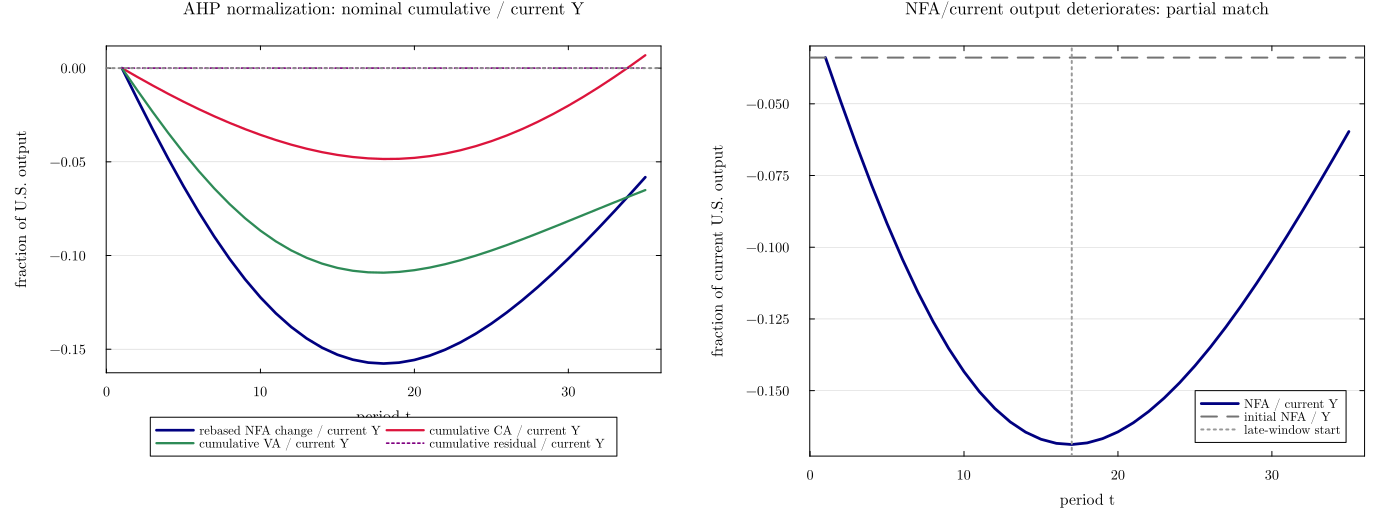

In [8]:
p_ahp = plot(tt, ahp_nfa_change_current_Y, color=:navy, lw=2.7,
                 label="rebased NFA change / current Y",
                 xlabel="period t", ylabel="fraction of U.S. output",
                 title="AHP normalization: nominal cumulative / current Y",
                 legend=:outerbottom, legend_columns=2)
plot!(p_ahp, tt, ahp_cum_CA_current_Y, color=:crimson, lw=2.3,
      label="cumulative CA / current Y")
plot!(p_ahp, tt, ahp_cum_VA_current_Y, color=:seagreen, lw=2.3,
      label="cumulative VA / current Y")
plot!(p_ahp, tt, ahp_cum_RES_current_Y, color=:purple, lw=1.7, ls=:dot,
      label="cumulative residual / current Y")
hline!(p_ahp, [0.0], color=:gray55, ls=:dot, label="")

nfa_ratio = final_ahp.NFA ./ Y
ratio_title = final_metrics.full_ratio_change < 0 ?
              "NFA/current output deteriorates: partial match" :
              "NFA/current output improves: mechanism near miss"
p_ratio = plot(tt, nfa_ratio, color=:navy, lw=2.8,
               label="NFA / current Y", xlabel="period t",
               ylabel="fraction of current U.S. output",
               title=ratio_title,
               legend=:bottomright)
hline!(p_ratio, [nfa_ratio[1]], color=:gray45, ls=:dash,
       label="initial NFA / Y")
vline!(p_ratio, [final_ahp.late_start], color=:gray60, ls=:dot,
       label="late-window start")

fig_ahp_two_panel = plot(p_ahp, p_ratio, layout=(1, 2),
                         size=(1400, 520), margin=9mm)
ahp_png = joinpath(OUTDIR, "best_ahp_two_panel.png")
savefig(fig_ahp_two_panel, ahp_png)

p_va = plot(late_plot_range,
            (final_ahp.late_cum_VA_asset ./ Y_end)[late_plot_range],
            color=:steelblue, lw=2.4, label="RoW-equity asset VA",
            xlabel="period t", ylabel="fraction of endpoint U.S. output",
            title="Late cumulative valuation subcomponents",
            legend=:outerbottom, legend_columns=2)
plot!(p_va, late_plot_range,
      (final_ahp.late_cum_VA_liability ./ Y_end)[late_plot_range],
      color=:tomato, lw=2.5, label="foreign-held U.S.-equity liability VA")
plot!(p_va, late_plot_range,
      (final_ahp.late_cum_VA ./ Y_end)[late_plot_range],
      color=:black, lw=2.0, ls=:dash, label="net VA")
hline!(p_va, [0.0], color=:gray55, ls=:dot, label="")

p_ca = plot(late_plot_range,
            (final_ahp.late_cum_CA_asset ./ Y_end)[late_plot_range],
            color=:steelblue, lw=2.3, label="RoW-equity quantity CA",
            xlabel="period t", ylabel="fraction of endpoint U.S. output",
            title="Late cumulative quantity-flow subcomponents",
            legend=:outerbottom, legend_columns=2)
plot!(p_ca, late_plot_range,
      (final_ahp.late_cum_CA_liability ./ Y_end)[late_plot_range],
      color=:tomato, lw=2.3, label="U.S.-equity liability quantity CA")
plot!(p_ca, late_plot_range,
      (final_ahp.late_cum_CA_bond ./ Y_end)[late_plot_range],
      color=:darkgreen, lw=2.3, label="bond-position CA")
plot!(p_ca, late_plot_range,
      (final_ahp.late_cum_CA ./ Y_end)[late_plot_range],
      color=:black, lw=2.0, ls=:dash, label="total CA")
hline!(p_ca, [0.0], color=:gray55, ls=:dot, label="")

fig_subcomponents = plot(p_va, p_ca, layout=(1, 2),
                         size=(1450, 520), margin=9mm)
subcomponents_png = joinpath(OUTDIR, "best_va_ca_subcomponents.png")
savefig(fig_subcomponents, subcomponents_png)

p_prices = plot(tt, final_ahp.q_US ./ final_ahp.q_US[1],
                color=:tomato, lw=2.5, label="U.S. equity price index",
                xlabel="period t", ylabel="index, t=1 equals 1",
                title="Equity prices", legend=:topleft)
plot!(p_prices, tt, final_ahp.q_W ./ final_ahp.q_W[1],
      color=:steelblue, lw=2.5, label="RoW equity price index")
vline!(p_prices, [final_ahp.late_start], color=:gray50, ls=:dash,
       label="late-window start")

p_exposure = plot(tt, final_ahp.liability_position ./ Y,
                  color=:tomato, lw=2.6,
                  label="foreign-held U.S. equity claims / current Y",
                  xlabel="period t", ylabel="fraction of current U.S. output",
                  title="Gross equity exposures", legend=:outerbottom,
                  legend_columns=2)
plot!(p_exposure, tt, final_ahp.asset_position ./ Y,
      color=:steelblue, lw=2.4, label="U.S.-held RoW equity / current Y")
plot!(p_exposure, tt, final_ahp.NFA ./ Y,
      color=:black, lw=2.0, ls=:dash, label="NFA / current Y")
hline!(p_exposure, [0.0], color=:gray55, ls=:dot, label="")

fig_prices_exposures = plot(p_prices, p_exposure, layout=(1, 2),
                            size=(1400, 500), margin=9mm)
prices_png = joinpath(OUTDIR, "best_prices_exposures.png")
savefig(fig_prices_exposures, prices_png)

println("\nPNG exports complete:")
foreach(path -> println("  ", path), [ahp_png, subcomponents_png, prices_png])

fig_ahp_two_panel


In [9]:
println("\n" * repeat("=", 78))
println("NOTEBOOK 15 FINAL SUMMARY")
println(repeat("=", 78))
println("Diagnosis: Notebook 12 raw cumulative CA is monotone; both normalized humps")
@printf("are denominator-driven: Y_US grows %.1fx and e_US grows %.1fx (the `_e` figure uses e_US).\n",
        base_Y_growth, base_e_growth)
println("Calibration restriction: common_world_growth=false; all primitives are literal")
println("and time invariant.")
println("Selection: ", best_spec.label, " at T=", final_T,
        " after every hard validity filter; classification=",
        final_row["economic_classification"], ".")
@printf("Fixed-endpoint mechanism: late dNFA=%+.4f, asset VA=%+.4f, liability VA=%+.4f, net VA=%+.4f, CA=%+.4f.\n",
        final_metrics.late_nfa_move, final_metrics.late_va_asset,
        final_metrics.late_va_liability, final_metrics.late_va_net,
        final_metrics.late_ca)
@printf("AHP direction check: late NFA/Y change=%+.4f, full NFA/Y change=%+.4f, full_path_match=%s.\n",
        final_metrics.late_ratio_change, final_metrics.full_ratio_change,
        final_metrics.full_path_match)
@printf("Mechanism diagnostics: liability dominance=%.3f, late foreign exposure=%.3f, late CA turnover reversal=%.3f.\n",
        final_metrics.liability_dominance, final_metrics.late_foreign_exposure,
        final_metrics.late_ca_backtracking)
println("The AHP 2010-2020 values (+.413, -1.036, -.623) enter only as")
println("secondary distance anchors. The selected time-invariant calibration isolates the")
println("liability-revaluation mechanism and the full-path NFA/Y direction, but not the")
println("late-window direction or AHP magnitudes.")
println("Artifacts are in: ", OUTDIR)
println(repeat("=", 78))



NOTEBOOK 15 FINAL SUMMARY
Diagnosis: Notebook 12 raw cumulative CA is monotone; both normalized humps
are denominator-driven: Y_US grows 499.9x and e_US grows 534.9x (the `_e` figure uses e_US).
Calibration restriction: common_world_growth=false; all primitives are literal
and time invariant.
Selection: F_foreign_target025 at T=35 after every hard validity filter; classification=partial_ahp_pattern.
Fixed-endpoint mechanism: late dNFA=-0.0385, asset VA=+0.0053, liability VA=-0.0567, net VA=-0.0514, CA=+0.0129.
AHP direction check: late NFA/Y change=+0.1091, full NFA/Y change=-0.0258, full_path_match=false.
Mechanism diagnostics: liability dominance=10.720, late foreign exposure=0.386, late CA turnover reversal=0.024.
The AHP 2010-2020 values (+.413, -1.036, -.623) enter only as
secondary distance anchors. The selected time-invariant calibration isolates the
liability-revaluation mechanism and the full-path NFA/Y direction, but not the
late-window direction or AHP magnitudes.
Artifacts

## Reading the selected calibration

A successful pattern match should be read in this order:

1. actual NFA / current U.S. output deteriorates over both the late and full windows;
2. the AHP-normalized rebased NFA change is negative;
3. liability VA is negative and larger in absolute value than asset VA;
4. the foreign-held U.S. equity exposure is economically large;
5. late CA and turnover-based flow reversal are small relative to the valuation channel;
6. all model, accounting, Psi, equity-weight, theta_US_star, and positive-claim filters pass.

Because the candidate catalog is intentionally small and all parameters are time invariant, `partial_ahp_pattern` means full-path NFA/current output deteriorates through the liability-revaluation mechanism but the stricter late-window gate still fails. A case whose full-path ratio also improves is explicitly labelled `liability_revaluation_near_miss`.
